In [1]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt


In [2]:
#img=cv2.imread("test_images/sharapova1.jpg")
img=cv2.imread("test_images/pass.jpg")
img.shape

(255, 210, 3)

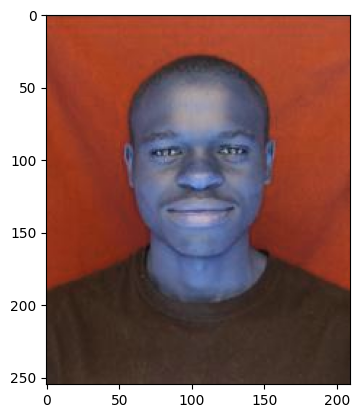

In [3]:
plt.imshow(img)

In [4]:
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(255, 210)

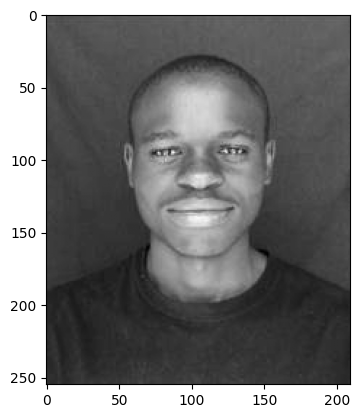

In [5]:
plt.imshow(gray,cmap='gray')

In [6]:
gray

array([[178, 175, 173, ..., 177, 176, 176],
       [ 75,  73,  71, ...,  83,  83,  83],
       [ 75,  73,  72, ...,  85,  84,  84],
       ...,
       [ 46,  46,  45, ...,  41,  44,  44],
       [ 47,  46,  45, ...,  41,  45,  45],
       [ 47,  46,  45, ...,  41,  44,  44]], shape=(255, 210), dtype=uint8)

In [7]:
face_cascade = cv2.CascadeClassifier( cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces


array([[ 49,  50, 115, 115]], dtype=int32)

In [8]:
(x,y,w,h)=faces[0]
x,y,w,h

(np.int32(49), np.int32(50), np.int32(115), np.int32(115))

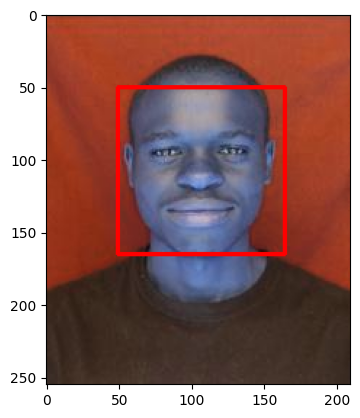

In [9]:
face_img=cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

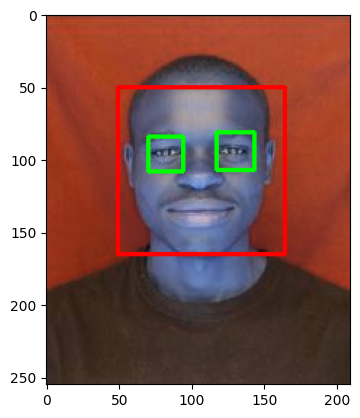

In [10]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()
        

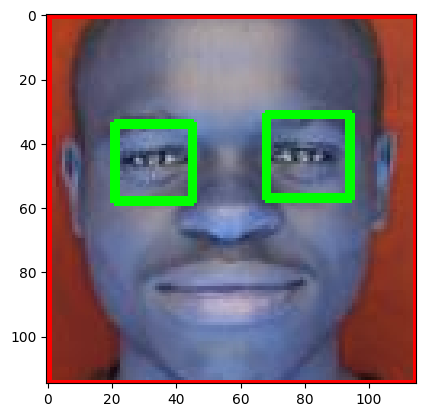

In [11]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')



In [12]:
def get_cropped_image_if_2_eyes(image_path):
    img=cv2.imread(image_path)
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces=face_cascade.detectMultiScale(gray,1.3,5)
    for (x,y,w,h) in faces:
        roi_gray=gray[y:y+h, x:x+w]
        roi_color=img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes)>=2:
            return roi_color
        
    

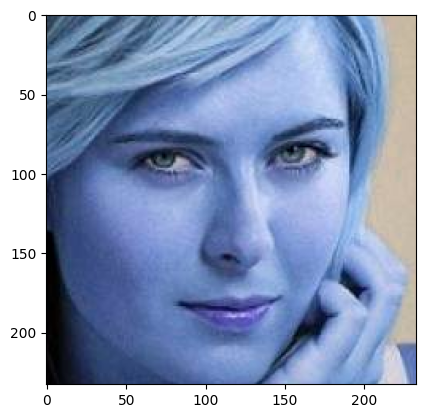

In [13]:
cropped_image=get_cropped_image_if_2_eyes("./test_images/sharapova1.jpg")
plt.imshow(cropped_image)

In [14]:
!pwd

/home/tinega/Documents/ML_DL/SportsPersonClassifier/model


In [15]:
ls


anaconda_projects/  clf/      requirements.txt
celebcl.ipynb       dataset/  test_images/


In [16]:
path_to_data="./dataset"
path_to_cr_data="./dataset/cropped/"
import os
img_dirs=[]
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)
        
    

In [17]:
img_dirs

['./dataset/roger_federer',
 './dataset/maria_sharapova',
 './dataset/cropped',
 './dataset/virat_kohli',
 './dataset/serena_williams',
 './dataset/lionel_messi']

In [18]:
import shutil

In [19]:
if os.path.exists(path_to_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [ ]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1    